# SH dynamical tropopause, January 2015–2025: mean, 2σ and 95th percentile of daily means

Source: Jülich Reanalysis Tropopause Data Repository (Hoffmann & Spang, 2022), v2, `era5low`
(1°, 6-hourly). https://datapub.fz-juelich.de/slcs/tropopause/ (CC BY 4.0, doi:10.26165/JUELICH-DATA/UBNGI2)

Final product: one row per month in `MONTHS` (this first iteration: January only), one column per statistic:
1. mean of daily-mean `dyn_z`
2. 2σ of daily means (ddof = 1)
3. empirical 95th percentile of daily means

To extend to Dec–Mar later, set `MONTHS = [12, 1, 2, 3]`; days already extracted are reused.

Each month pools all 11 years. σ therefore includes day-to-day, intraseasonal and interannual variability.

**Stages**
1. Extract: download each file, keep `dyn_z` at 30–90°S, average the 4 time steps, and write one small
   netCDF per day. Resumable: days already extracted are skipped.
2. Statistics per calendar month.
3. Plot.

`dyn_z` is geopotential height [km]. The 43,000 ft reference contour is the geometric altitude
43,000 ft converted to geopotential height at each latitude (about 13.06–13.11 km, versus 13.106 km geometric).
This assumes 43,000 ft means geometric altitude; if it means flight level (pressure altitude), the right
comparison is against `dyn_p` instead.

In [11]:
import glob
import os
import sys
import tempfile
import time
import urllib.error
import urllib.request
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import date, timedelta

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

# ---- configuration ----
BASE_URL = "https://datapub.fz-juelich.de/slcs/tropopause/data/v2/era5low"
YEARS = (2015, 2025)             # inclusive
MONTHS = [12, 1, 2, 3]                     # row order in the final figure; later [12, 1, 2, 3]
LAT_MAX = -30.0
VAR = "dyn_z"
WORKERS = 4                      # parallel downloads
DAILY_DIR = "dyn_z_daily"        # stage-1 output, one file per day (~90 kB each)
TAG = "".join(f"{m:02d}" for m in MONTHS)
STATS_FILE = f"dyn_z_stats_{YEARS[0]}-{YEARS[1]}_m{TAG}.nc"
FIG_FILE = f"dyn_z_mean_2sd_p95_{YEARS[0]}-{YEARS[1]}_m{TAG}.png"
QUANTILE = 0.95

MONTH_NAMES = {12: "Dec", 1: "Jan", 2: "Feb", 3: "Mar"}
os.makedirs(DAILY_DIR, exist_ok=True)

## Stage 1: extract daily means

Downloads run in worker threads. Reading and writing netCDF happens only in the main thread,
because HDF5 is not thread-safe. Each 19 MB download is deleted as soon as it has been reduced.
Missing dates (HTTP 404) and failed downloads are listed at the end; re-running the cell retries only
the days that are not yet on disk.

In [12]:
def all_days():
    for y in range(YEARS[0], YEARS[1] + 1):
        for m in MONTHS:
            d = date(y, m, 1)
            while d.month == m:
                yield d
                d += timedelta(days=1)


def url_for(d):
    return f"{BASE_URL}/{d.year}/era5low_{d.year}_{d.month:02d}_{d.day:02d}.nc"


def out_path(d):
    return os.path.join(DAILY_DIR, f"{VAR}_{d.isoformat()}.nc")


def download(d, tmpdir, retries=4):
    """Return (date, path, status); status is 'ok', 'missing' (404) or an error string."""
    dest = os.path.join(tmpdir, f"{d.isoformat()}.nc")
    err = None
    for k in range(retries):
        try:
            with urllib.request.urlopen(url_for(d), timeout=180) as r, open(dest, "wb") as f:
                while chunk := r.read(1 << 20):
                    f.write(chunk)
            return d, dest, "ok"
        except urllib.error.HTTPError as e:
            if e.code == 404:
                return d, None, "missing"
            err = e
        except Exception as e:  # noqa: BLE001
            err = e
        time.sleep(2 ** k)
    if os.path.exists(dest):
        os.remove(dest)
    return d, None, f"failed: {err}"


def reduce_and_write(d, path):
    with xr.open_dataset(path) as ds:
        z = ds[VAR].sel(lat=slice(-90, LAT_MAX)).sel(lon=slice(-180, 179.5)).load()  # drop lon=180 (duplicate of -180)
    assert z.attrs.get("units") == "km", z.attrs
    nstep = z.sizes["time"]
    daily = z.mean("time", skipna=True).expand_dims(time=[np.datetime64(d.isoformat(), "ns")])
    nvalid = z.notnull().sum("time").astype("int8").expand_dims(time=daily.time)
    out = xr.Dataset({VAR: daily.astype("float32"), "nvalid": nvalid})
    out[VAR].attrs = dict(z.attrs, cell_methods="time: mean (daily, over 6-hourly steps)")
    out["nvalid"].attrs = dict(long_name=f"number of valid 6-hourly values (of {nstep})")
    tmp = out_path(d) + ".part"
    out.to_netcdf(tmp)
    os.replace(tmp, out_path(d))   # atomic: a partial file never looks finished


days = list(all_days())
todo = [d for d in days if not os.path.exists(out_path(d))]
print(f"{len(days)} days in {YEARS[0]}-{YEARS[1]}, months {MONTHS}; {len(todo)} to extract")

missing, failed = [], []
tmpdir = tempfile.mkdtemp(prefix="trop_")
t0 = time.time()
with ThreadPoolExecutor(WORKERS) as pool:
    futs = [pool.submit(download, d, tmpdir) for d in todo]
    for i, fu in enumerate(as_completed(futs), 1):
        d, path, status = fu.result()
        if status == "missing":
            missing.append(d)
        elif status != "ok":
            failed.append((d, status))
        else:
            try:
                reduce_and_write(d, path)
            except Exception as e:  # noqa: BLE001
                failed.append((d, f"reduce: {e}"))
            finally:
                os.remove(path)
        if i % 50 == 0 or i == len(todo):
            print(f"  {i}/{len(todo)}  {time.time() - t0:.0f} s  missing={len(missing)} failed={len(failed)}")

print("missing (404):", sorted(missing))
print("failed:", sorted(failed))

1334 days in 2015-2025, months [12, 1, 2, 3]; 993 to extract


  50/993  33 s  missing=0 failed=0


  100/993  65 s  missing=0 failed=0


  150/993  96 s  missing=0 failed=0


  200/993  128 s  missing=0 failed=0


...

  800/993  509 s  missing=0 failed=0


  850/993  541 s  missing=0 failed=0


  900/993  573 s  missing=0 failed=0


  950/993  604 s  missing=0 failed=0


  993/993  631 s  missing=0 failed=0
missing (404): []
failed: []


In [13]:
# the above takes about 5-10 mins to run per month

## Stage 2: monthly statistics

Load the daily files for `MONTHS` (about 30 MB for January), check coverage, then compute per calendar month:
mean, σ (ddof = 1) and the empirical 95th percentile of the daily means. The statistics are saved to
`STATS_FILE`, so stage 3 can be re-run on its own.

In [26]:
QUANTILES = {"z_p90":0.90, "z_p95": 0.95, "z_p99": 0.99}

files = [out_path(d) for d in all_days() if os.path.exists(out_path(d))]   # only MONTHS
daily = xr.concat([xr.load_dataset(f) for f in files], dim="time").sortby("time")   # no dask needed
z = daily[VAR]

# coverage check
per_month_year = z.time.to_series().groupby([z.time.dt.month.values, z.time.dt.year.values]).size().unstack(0)
print("days per (year, month):")
print(per_month_year[MONTHS].fillna(0).astype(int))
print(f"\nfraction of 6-hourly values missing: {1 - daily.nvalid.sum().item() / (4 * daily.nvalid.size):.2e}")
print(f"grid points with no valid daily mean on some day: {int(z.isnull().any('time').sum())}")

g = z.groupby("time.month")
q = g.quantile(list(QUANTILES.values()), dim="time", skipna=True)
stats = xr.Dataset(dict(
    z_mean=g.mean("time", skipna=True),
    z_2sd=2 * g.std("time", skipna=True, ddof=1),
    **{k: q.sel(quantile=v).drop_vars("quantile") for k, v in QUANTILES.items()},
    n_days=z.notnull().groupby("time.month").sum("time"),
)).sel(month=MONTHS)
long_names = dict(z_mean="mean of daily-mean dynamical tropopause height",
                  z_2sd="2 x std (ddof=1) of daily means",
                  **{k: f"empirical {round(v * 100)}th percentile of daily means" for k, v in QUANTILES.items()})
for v, ln in long_names.items():
    stats[v].attrs = dict(units="km", long_name=ln, height_type="geopotential")
stats["z_mean_p2sd"] = stats.z_mean + stats.z_2sd   # for comparison with the percentiles only
stats["z_mean_p2sd"].attrs = dict(units="km", long_name="mean + 2 std (not plotted)")
stats.attrs = dict(source="Juelich Reanalysis Tropopause Data Repository v2 era5low, doi:10.26165/JUELICH-DATA/UBNGI2",
                   variable=VAR, years=f"{YEARS[0]}-{YEARS[1]}",
                   note="each calendar month pools all years; statistics of daily means over 6-hourly steps")
stats.to_netcdf(STATS_FILE)

print("\ndays per month (min over grid):", stats.n_days.min(["lat", "lon"]).values)
for k in QUANTILES:
    print(f"median over grid of {k} - (mean + 2sd) [km]:",
          np.round((stats[k] - stats.z_mean_p2sd).median(["lat", "lon"]).values, 3))

days per (year, month):
      12  1   2   3 
2015  31  31  28  31
2016  31  31  29  31
2017  31  31  28  31
2018  31  31  28  31
2019  31  31  28  31
2020  31  31  29  31
2021  31  31  28  31
2022  31  31  28  31
2023  31  31  28  31
2024  31  31  29  31
2025  31  31  28  31

fraction of 6-hourly values missing: 1.93e-04
grid points with no valid daily mean on some day: 224



days per month (min over grid): [341 340 310 334]
median over grid of z_p90 - (mean + 2sd) [km]: [-0.705 -0.682 -0.676 -0.73 ]
median over grid of z_p95 - (mean + 2sd) [km]: [-0.304 -0.285 -0.255 -0.288]
median over grid of z_p99 - (mean + 2sd) [km]: [0.389 0.428 0.363 0.355]


## Stage 3: plot

wrote dyn_z_mean_2sd_p95_p99_2015-2025_m12010203.png


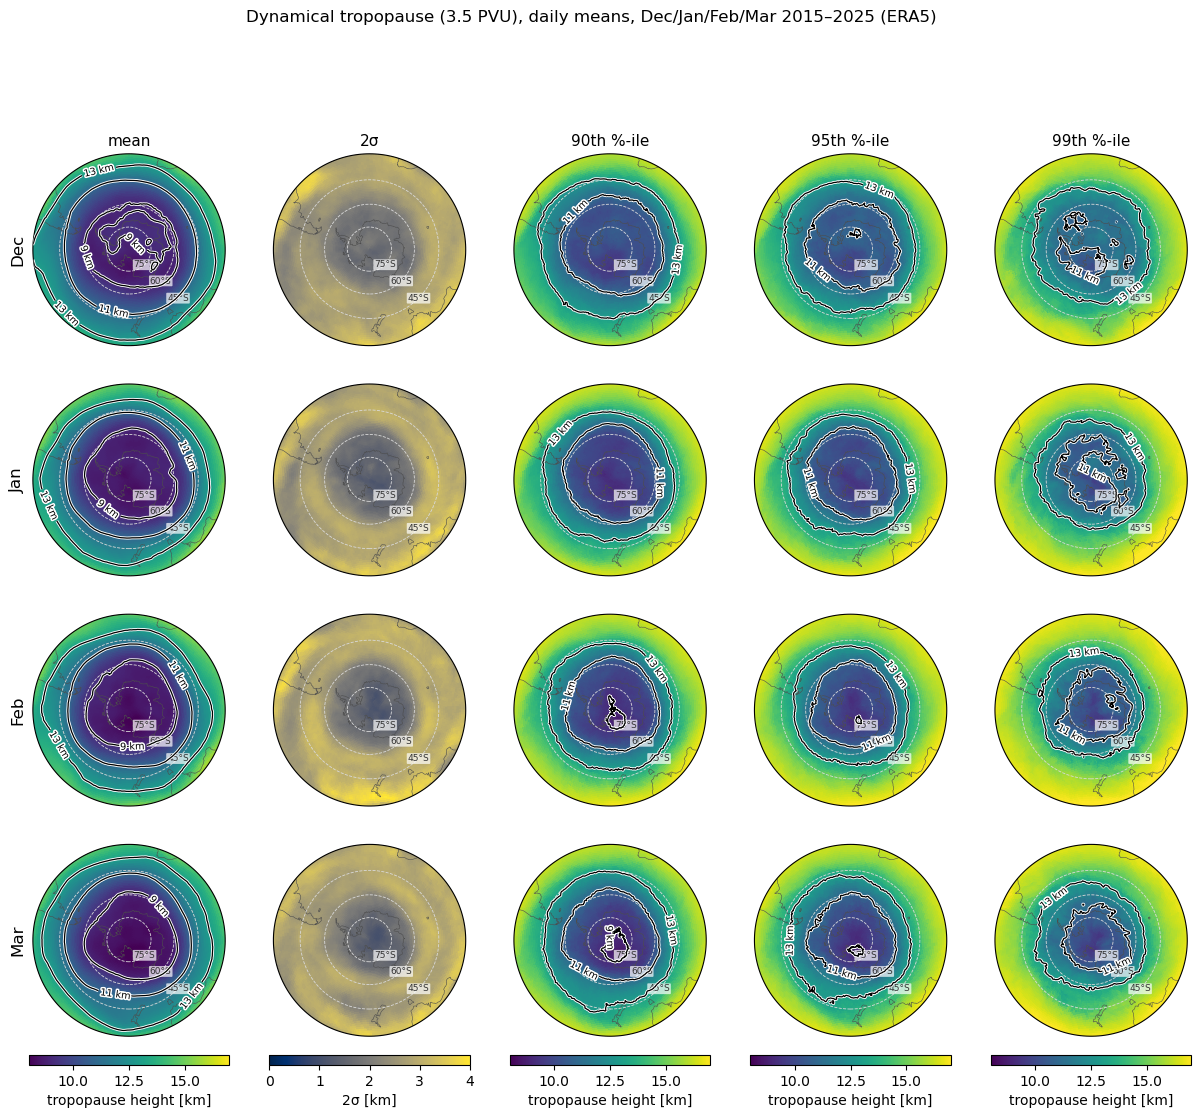

In [28]:
import matplotlib
import matplotlib.patheffects as pe

CONTOURS_KM = [9.0, 11.0, 13.0]
LAT_LINES = [-45, -60, -75]
LAT_LABEL_LON = 135          # longitude at which the latitude-line labels are written
FIG_FILE = f"dyn_z_mean_2sd_p95_p99_{YEARS[0]}-{YEARS[1]}_m{TAG}.png"

stats = xr.open_dataset(STATS_FILE)
lat, lon = stats.lat.values, stats.lon.values

h_lo = np.floor(float(stats.z_mean.quantile(0.01)) * 2) / 2
h_hi = np.ceil(float(stats.z_p99.quantile(0.99)) * 2) / 2
s_hi = np.ceil(float(stats.z_2sd.quantile(0.99)) * 2) / 2
cols = [("z_mean", "mean", "viridis", h_lo, h_hi, True),
        ("z_2sd", "2σ", "cividis", 0, s_hi, False),
        ("z_p90", "90th %-ile", "viridis", h_lo, h_hi, True),
        ("z_p95", "95th %-ile", "viridis", h_lo, h_hi, True),
        ("z_p99", "99th %-ile", "viridis", h_lo, h_hi, True)]

theta = np.linspace(0, 2 * np.pi, 200)
circle = mpath.Path(np.vstack([np.sin(theta), np.cos(theta)]).T * 0.5 + 0.5)
pc = ccrs.PlateCarree()
halo = [pe.withStroke(linewidth=2.2, foreground="w")]
lon_line = np.linspace(-180, 180, 361)

nrow, ncol = len(MONTHS), len(cols)
fig, axs = plt.subplots(nrow, ncol, figsize=(3 * ncol, 3 * nrow), squeeze=False,
                        subplot_kw=dict(projection=ccrs.SouthPolarStereo()))
ims = {}
for i, m in enumerate(MONTHS):
    for j, (v, title, cmap, vmin, vmax, is_height) in enumerate(cols):
        ax = axs[i, j]
        ax.set_extent([-180, 180, -90, LAT_MAX], pc)
        ax.set_boundary(circle, transform=ax.transAxes)
        data, lonc = add_cyclic_point(stats[v].sel(month=m).values, coord=lon)
        ims[j] = ax.pcolormesh(lonc, lat, data, cmap=cmap, vmin=vmin, vmax=vmax,
                               shading="auto", transform=pc, rasterized=True)
        ax.coastlines(lw=0.4, color="0.3")

        # latitude bands
        for la in LAT_LINES:
            ax.plot(lon_line, np.full_like(lon_line, la), transform=pc,
                    color="0.85", lw=0.6, ls="--", zorder=3)
            ax.text(LAT_LABEL_LON, la, f"{-la}°S", transform=pc, fontsize=6.5, color="0.2",
                    ha="center", va="center", zorder=4,
                    bbox=dict(boxstyle="round,pad=0.1", fc="w", ec="none", alpha=0.7))

        # height contours with inline labels
        if is_height:
            cs = ax.contour(lonc, lat, data, levels=CONTOURS_KM, colors="k", linewidths=0.9,
                            transform=pc, zorder=5)
            if isinstance(cs, matplotlib.artist.Artist):      # matplotlib >= 3.8
                cs.set_path_effects(halo)
            else:
                for c in cs.collections:
                    c.set_path_effects(halo)
            lbl = ax.clabel(cs, fmt="%g km", fontsize=7, inline=True, inline_spacing=3)
            plt.setp(lbl, path_effects=halo)

        if i == 0:
            ax.set_title(title, fontsize=11)
        if j == 0:
            ax.text(-0.08, 0.5, MONTH_NAMES[m], transform=ax.transAxes, rotation=90,
                    va="center", ha="center", fontsize=12)

for j, (v, title, *_, is_height) in enumerate(cols):
    lab = "tropopause height [km]" if is_height else "2σ [km]"
    fig.colorbar(ims[j], ax=axs[:, j], orientation="horizontal", fraction=0.1 / nrow, pad=0.08 / nrow,
                 aspect=20, label=lab)
fig.suptitle(f"Dynamical tropopause (3.5 PVU), daily means, {'/'.join(MONTH_NAMES[m] for m in MONTHS)} "
             f"{YEARS[0]}–{YEARS[1]} (ERA5)",
             y=1.0 if nrow > 1 else 1.05)
fig.savefig(FIG_FILE, bbox_inches="tight", dpi=200)
print("wrote", FIG_FILE)
plt.show()